# 📋 INSTRUCTOR NOTEBOOK — Time Series Foundations: Visualization and Decomposition

**Module 0 · Lesson 1 of 13 · Instructor edition**  
**Estimated class time:** 75–90 minutes  
**Source sequence:** Original Day 1  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Explain why temporal ordering changes how data should be analyzed.
- Identify trend, seasonality, and changing variance in a time plot.
- Interpret a multiplicative seasonal decomposition.

---
## 📣 Segment 0 — Welcome & Framing (15 min)

### Talking Points

**Open with a motivating question (give students ~1 min to think, then discuss):**
> *"You have 3 years of monthly sales data. Why can't you just shuffle the rows and train a
> standard regression model?"*

Key answer: Order matters. Shuffling destroys temporal structure and causes data leakage
(future data leaks into training set).

Factors that influence time-series:
* how well we understand the factors that contribute to it;
* how much data is available;
* how similar the future is to the past;
* whether the forecasts can affect the thing we are trying to forecast.

**Frame the week:** Today is diagnostic day. Before we model anything, we learn to *look*
at a series carefully — just like you'd explore tabular data with histograms and scatter
plots before fitting a regression.

**Reassure beginners:** All syntax is explained in-line. Encourage students to read the
hints carefully before asking for help.

### Common First-Day Questions
- *"What's the difference between time series and panel data?"*
  → Time series = one entity measured repeatedly. Panel = many entities. Keep it simple today.
- *"Do we need to know the math?"*
  → Conceptual understanding is the goal. We'll see formulas but won't derive everything today.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


> 🗣️ **Instructor note:** Briefly introduce each import group. Many students won't know
> `statsmodels` — normalize it as the go-to library for classical statistics in Python.
> Don't dwell here; just name each group and move on.

---
## 📣 Segment 1 — Load & Visualize (25 min)

### Talking Points
- **Q:** Why would this data be appropriate to investigate as a time series?
- Air Passengers is pedagogically ideal: it has trend *and* seasonality, it's small (144 rows), and students can reason about it intuitively (summer = more vacation travel).
- Point out `parse_dates` and `index_col` as essential habits for time series in pandas.
  A DatetimeIndex unlocks resampling, rolling windows, and date-aware plotting.
- Consistently use `fig, ax = plt.subplots()` pattern all week — it avoids confusion
  between the procedural and object-oriented matplotlib APIs.

### ⚠️ Common Mistakes
- **Forgetting `parse_dates`**: The index will be strings, not dates — plots will look wrong
  or throw errors. Show the difference if a student hits this.
- **Using `plt.plot()` instead of `ax.plot()`**: Briefly explain the two APIs coexist;
  we standardize on `ax.plot()` for clarity.

In [ ]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date','Passengers']
print('Shape:', df.shape)
df.head(10)

Shape: (144, 2)


,Date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


### ✅ ANSWER — 1.2 Plot (fill-in solution)

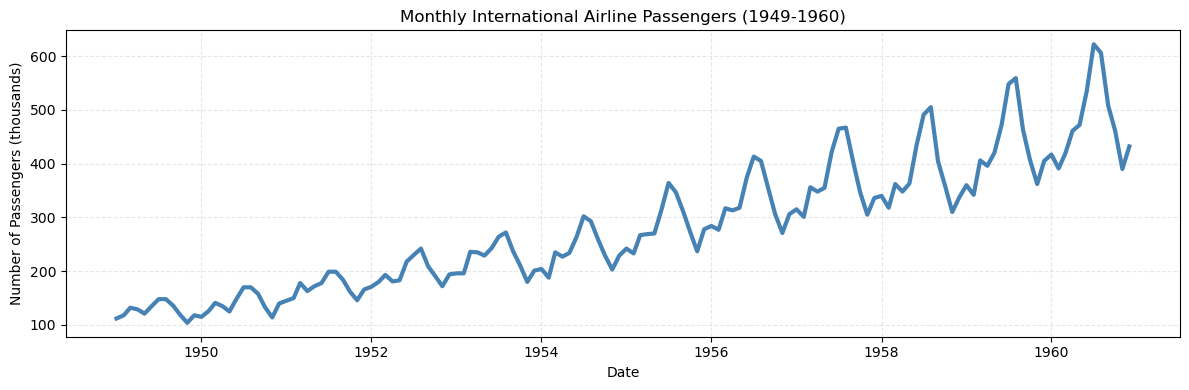

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['Date'], df['Passengers'], color='steelblue', linewidth=3)  # SOLUTION
ax.set_title('Monthly International Airline Passengers (1949-1960)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Passengers (thousands)')  # SOLUTION
plt.tight_layout()
plt.grid(linestyle="--")
plt.show()

### ✅ MODEL ANSWER — Written Response 1.2

> The series shows a clear **upward trend** — passenger counts roughly triple over 12 years.
> There is strong **annual seasonality**: a visible spike each summer (July–August) reflecting
> vacation travel. Critically, the **variance is not constant** — the seasonal swings grow
> much larger in later years. This growing variance is a key indicator of non-stationarity
> and motivates a multiplicative decomposition model.

**Grading note:** Award credit for all three features: trend, seasonality, growing variance.
Students who omit variance should be prompted to compare the amplitude of swings in 1949 vs 1960.

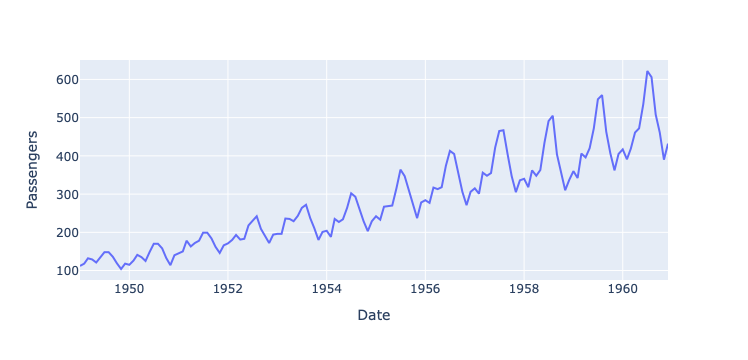

In [ ]:
fig = px.line(df, x='Date', y="Passengers")
fig.show()

---
## 📣 Segment 2 — Decomposition (30 min)

We can formally split a time series into three components:
- **Trend**: the long-run direction
- **Seasonality**: regular, repeating fluctuations (e.g., every 12 months)
- **Residual**: what remains after removing trend and seasonality (ideally random noise)

$$\text{Observed} = \text{Trend} \times \text{Seasonal} \times \text{Residual}$$


### Talking Points
- **Additive vs. Multiplicative** — write both on the board:
  - Additive (use when seasonal amplitude is constant):
    $$
    y_t = T_t + S_t + R_t,
    $$
    where $y_t$ is the data,  $S_t$ is the seasonal component, $T_t$ is the trend-cycle component, and $R_t$ is the remainder component, all at period $t$.

The additive decomposition is the most appropriate if:
- the magnitude of the seasonal fluctuations, or
- the variation around the trend-cycle, does not vary with the level of the time series.

When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a multiplicative decomposition is more appropriate. Multiplicative decompositions are common with economic time series.

  - Multiplicative (use when seasonal amplitude grows with the trend): $y_t = T_t × S_t × R_t$.
  - Rule of thumb: if the seasonal swings look like a funnel opening up → multiplicative.
- After running, ask: *"If we had a perfect model, what would the residuals look like?"*
  Answer: white noise — no structure, oscillating around 1.0 for multiplicative.

### ⚠️ Common Mistakes
- **Wrong `period`**: Students try `period=1` or `period=52`. Clarify: monthly data with
  annual seasonality → `period=12`.
- **Boundary NaN values**: The trend and residual panels will have NaN at both ends
  (due to the centered moving average). This is expected — flag it proactively so students
  don't think something is broken.
- **Ignoring residuals**: Push students to look at the residual panel, not just trend/seasonal.

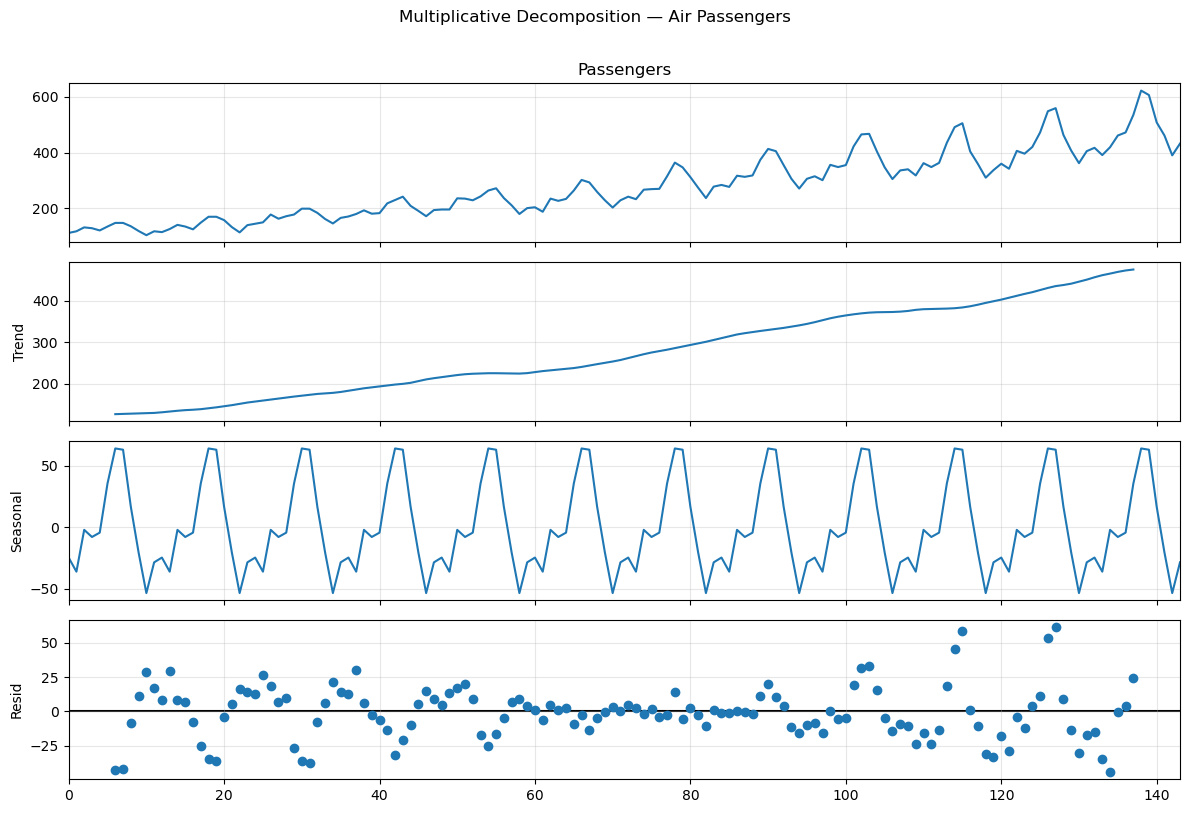

In [ ]:
result = seasonal_decompose(df['Passengers'], model='additive', period=12)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Multiplicative Decomposition — Air Passengers', y=1.01)
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 2.1

> **Trend:** Smooth, steady increase throughout the 1950s, consistent with post-WWII economic
> growth and commercialization of aviation.
>
> **Seasonal:** Strong, consistent annual pattern peaking ~1.2–1.3x average in summer months
> and troughing in winter — expected vacation travel patterns.
>
> **Residual:** Oscillates around 1.0 without strong patterns — approximately what we want.
> Slight deviations near the series boundaries are expected (centered MA loses observations
> at each end).